# **Amazon E-Commerce Products & Reviews Analysis**


**Name:** Palak Gupta  
**Enrollment No:** 240566
**Section:** CSE 5 
**Course Name:** Data Analytics Using Python  
**Course Code:** CSE2101 
**Supervisor / Faculty:** Ms. Anusha Chhabra  

## Project Description:
This project analyzes an Amazon Clothing & Accessories dataset sourced from Kaggle to explore what drives product pricing and customer engagement. I perform data cleaning, convert text based numeric fields, handle missing values and encode categorical features. Using exploratory data analysis (EDA) with histograms, boxplots and heatmaps. I identify key patterns and relationships among features. Finally, I performed some clustering to predict product price (or ratings) and extract insights useful for e-commerce analytics and recommendation strategies.

## Objective:
1) Analyze product categories, price distribution and ratings.
2) Explore relationships between features like brand, category, price and ratings.
3) Build a simple predictive/clustering model (such as rating prediction or product segmentation).
4) Generate actionable insights for business or customer analysis.

## Dataset Source
1) Source: Kaggle, https://www.kaggle.com/datasets/lazylad99/amazon-e-commerce-product-and-review-dataset
2) Description: Detailed metadata on men’s clothing/accessory products, including descriptions, price, rank, sellers, brands and other catalog data.
3) Rows: 1011, Columns: 34

## Variable Types:
1) **Numerical:** s.no, rank_1, price_value,etc. 
2) **Categorical:** Most columns (brand_name, availability, etc.)
3) **Text:** Descriptions, names,etc.
4) **Date:** Not directly present, but delivery dates could be parsed

In [ ]:
##Importing certain libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## STEP 1: Problem Definition & Dataset Selection


### Importing Datasets

In [13]:
products=pd.read_csv("products.csv")
display(products.head())

,s.no,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,...,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images,rank_1
0,0,Premium Comfort: Crafted from a high-quality c...,B0B59BJG6Y,In Stock,"#56,836 in Clothing, Shoes & Jewelry (See Top ...",MLYENX Store,https://www.amazon.com/stores/MLYENX/page/1FCD...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",Customers find the shirts comfortable and well...,size:Large,...,15%,75%,4.6 out of 5 stars,50+ bought,03-10-2025 21:42,Greenfive,https://www.amazon.com/gp/help/seller/at-a-gla...,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,['https://m.media-amazon.com/images/I/41yUF65P...,85.0
1,1,Material: Men's polo shirt is made of soft pol...,B0DLGB4RYH,In Stock,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",COOFANDY Store,https://www.amazon.com/stores/COOFANDY/page/23...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",NaN,size:X-Large,...,17%,66%,4.4 out of 5 stars,NaN,03-10-2025 21:42,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-gla...,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,['https://m.media-amazon.com/images/I/31a3mSs3...,199.0
2,2,"PERFORMANCE:These men polo shirts are soft,lig...",B0DRXF62JH,In Stock,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",ZITY Store,https://www.amazon.com/stores/ZITY/page/F582B6...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",NaN,size:X-Large,...,37%,63%,4.6 out of 5 stars,NaN,03-10-2025 21:42,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,['https://m.media-amazon.com/images/I/41J5q-Ua...,111.0
3,3,【Material】: These golf shirts for men are made...,B0DK5FZ325,In Stock,"#194,649 in Clothing, Shoes & Jewelry (See Top...",Rouen Store,https://www.amazon.com/stores/ROUEN/page/4C407...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",NaN,size:Small,...,20%,80%,4.8 out of 5 stars,NaN,03-10-2025 21:43,MICHEL ROUEN,https://www.amazon.com/gp/help/seller/at-a-gla...,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,['https://m.media-amazon.com/images/I/31J1ttvf...,266.0
4,4,MOISTURE WICKING: The fabric of the summer gol...,B0BGXTC1FR,In Stock,"#3,664 in Clothing, Shoes & Jewelry (See Top 1...",V VALANCH Store,https://www.amazon.com/stores/VVALANCH/page/0E...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",Customers find the shirt has a good fit and lo...,size:X-Large,...,17%,69%,4.4 out of 5 stars,NaN,03-10-2025 21:43,Zhengdaqian,https://www.amazon.com/gp/help/seller/at-a-gla...,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,['https://m.media-amazon.com/images/I/31Ff+3Ib...,11.0


In [15]:
#Describing Dataset
print(products.shape)
products.info()
products.describe(include='all')

(728, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   s.no                       728 non-null    int64  
 1   about_item                 728 non-null    object 
 2   asin                       728 non-null    object 
 3   availability               715 non-null    object 
 4   best_sellers_rank          558 non-null    object 
 5   brand_name                 728 non-null    object 
 6   brand_page_url             649 non-null    object 
 7   breadcrumbs                715 non-null    object 
 8   customer_review_summary    634 non-null    object 
 9   default_variant/0          696 non-null    object 
 10  default_variant/1          658 non-null    object 
 11  default_variant/2          1 non-null      object 
 12  delivery_date              702 non-null    object 
 13  fastest_delivery_date      667 non-null 

,s.no,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,...,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images,rank_1
count,728.000000,728,728,715,558,728,649,715,634,696,...,728,728,719,569,728,707,426,728,728,540.000000
unique,NaN,697,728,11,539,285,237,140,616,118,...,33,63,24,19,120,267,426,704,714,NaN
top,NaN,"Textured fabric that's soft, light & breathabl...",B0B59BJG6Y,In Stock,"#67 in Clothing, Shoes & Jewelry (See Top 100 ...",Hanes Store,https://www.amazon.com/stores/Hanes/page/F8302...,"Clothing, Shoes & Jewelry › Men › Clothing › J...",Customers find the shirt has a good fit and st...,size:Large,...,15%,75%,4.5 out of 5 stars,100+ bought,03-10-2025 22:38,Amazon.com,https://www.amazon.com/gp/help/seller/at-a-gla...,Under Armour Men's Tech Golf Polo,['https://m.media-amazon.com/images/I/31mfMfV8...,NaN
freq,NaN,3,1,640,3,35,35,52,3,168,...,89,44,131,108,18,278,1,3,2,NaN
mean,423.361264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.622222
std,293.923401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.115097
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,184.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
50%,371.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.500000
75%,553.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220.250000


## STEP 2: Data Cleaning and Preparation 

In this step, we prepare the dataset for analysis and modeling through essential preprocessing tasks. These include:
1) Checking and handling missing values (using imputation or removal).
2) Removing duplicate records for clean and accurate data.
3) Dropping irrelevant columns that do not add analytical value.
4) Treating outliers in numerical features using IQR or Z-score methods.
5) Encoding categorical variables (brand, category) using Label Encoding or One-Hot Encoding.
6) Scaling numerical features where required for modeling.

### Checking missing values

In [21]:
products.isnull().sum()

s.no                           0
about_item                     0
asin                           0
availability                  13
best_sellers_rank            170
brand_name                     0
brand_page_url                79
breadcrumbs                   13
customer_review_summary       94
default_variant/0             32
default_variant/1             70
default_variant/2            727
delivery_date                 26
fastest_delivery_date         61
list_price                   327
manufacturer                 462
model_number                 529
price_value                   21
product_description          457
product_url                    0
rating_count                   9
rating_distribution/1star      0
rating_distribution/2star      0
rating_distribution/3star      0
rating_distribution/4star      0
rating_distribution/5star      0
rating_stars                   9
recent_purchases             159
scrape_time                    0
seller_name                   21
seller_pag

### Handling Missing values

In [143]:
# Fill numeric columns with mean
num_cols = products.select_dtypes(include='number').columns
products[num_cols] = products[num_cols].fillna(products[num_cols].mean())

# Fill categorical columns with 'Unknown'
cate_cols = products.select_dtypes(include='object').columns
products[cate_cols] = products[cate_cols].fillna('Unknown')

print("\nAfter handling missing values:")
print("Products dataset:\n", products.isnull().sum())

# this approach keeps most of the data intact and maintain accuracy by removing mostly empty columns.


After handling missing values:
Products dataset:
 s.no                         0
about_item                   0
asin                         0
availability                 0
best_sellers_rank            0
brand_name                   0
brand_page_url               0
breadcrumbs                  0
customer_review_summary      0
default_variant/0            0
default_variant/1            0
default_variant/2            0
delivery_date                0
fastest_delivery_date        0
list_price                   0
manufacturer                 0
model_number                 0
price_value                  0
product_description          0
product_url                  0
rating_count                 0
rating_distribution/1star    0
rating_distribution/2star    0
rating_distribution/3star    0
rating_distribution/4star    0
rating_distribution/5star    0
rating_stars                 0
recent_purchases             0
scrape_time                  0
seller_name                  0
seller_page_url    

### Removing duplicates and irrelevant columns

In [89]:
# Remove duplicates
products = products.drop_duplicates()

# Remove irrelevant columns
products = products.drop(['brand_page_url', 'all_images', 'scrape_time'], axis=1, errors='ignore')

# Preview first 2 rows and shape
print("Products dataset preview:")
display(products.head(2))
print("\nProducts dataset shape:", products.shape)

Products dataset preview:


,s.no,about_item,asin,availability,best_sellers_rank,brand_name,breadcrumbs,customer_review_summary,default_variant/0,default_variant/1,...,rating_distribution/2star,rating_distribution/3star,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,seller_name,seller_page_url,title,rank_1
0,0,Premium Comfort: Crafted from a high-quality c...,B0B59BJG6Y,In Stock,"#56,836 in Clothing, Shoes & Jewelry (See Top ...",MLYENX Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",Customers find the shirts comfortable and well...,size:Large,"color:5 Pack Black, Dark Grey, Light Blue, Mil...",...,1%,7%,15%,75%,4.6 out of 5 stars,50+ bought,Greenfive,https://www.amazon.com/gp/help/seller/at-a-gla...,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,85.0
1,1,Material: Men's polo shirt is made of soft pol...,B0DLGB4RYH,In Stock,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",COOFANDY Store,"Clothing, Shoes & Jewelry › Men › Clothing › S...",NaN,size:X-Large,color:Light Grey,...,6%,11%,17%,66%,4.4 out of 5 stars,NaN,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-gla...,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,199.0



Products dataset shape: (728, 31)


### Handling Outliers using IQR method

In [91]:
Q1 = products['price_value'].quantile(0.25)
Q3 = products['price_value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Detecting outliers
outliers = products[(products['price_value'] < lower) | (products['price_value'] > upper)]
print(f"Number of outliers detected: {len(outliers)}")

# Handling by clipping
products['price_value'] = products['price_value'].clip(lower, upper)
print("Outliers have been capped to the IQR bounds.")
print(products.head())


Number of outliers detected: 33
Outliers have been capped to the IQR bounds.
   s.no                                         about_item        asin  \
0     0  Premium Comfort: Crafted from a high-quality c...  B0B59BJG6Y   
1     1  Material: Men's polo shirt is made of soft pol...  B0DLGB4RYH   
2     2  PERFORMANCE:These men polo shirts are soft,lig...  B0DRXF62JH   
3     3  【Material】: These golf shirts for men are made...  B0DK5FZ325   
4     4  MOISTURE WICKING: The fabric of the summer gol...  B0BGXTC1FR   

  availability                                  best_sellers_rank  \
0     In Stock  #56,836 in Clothing, Shoes & Jewelry (See Top ...   
1     In Stock  #50,261 in Clothing, Shoes & Jewelry (See Top ...   
2     In Stock  #69,641 in Clothing, Shoes & Jewelry (See Top ...   
3     In Stock  #194,649 in Clothing, Shoes & Jewelry (See Top...   
4     In Stock  #3,664 in Clothing, Shoes & Jewelry (See Top 1...   

        brand_name                                        bread

### Encode categorical data (Label Encoding / One-Hot Encoding).

In [57]:
from sklearn.preprocessing import LabelEncoder

# Select categorical columns
cat_cols = [col for col in products.select_dtypes(include='object').columns 
            if col not in ['about_item', 'product_description']]

# Encode categorical columns with Label Encoding only
for col in cat_cols:
    products[col] = products[col].astype('category').cat.codes  # 0,1,2… for all categories

print("Products dataset after clean encoding:")
display(products.iloc[:, :10].head(2))
print("Total columns now:", products.shape[1])


Products dataset after clean encoding:


,s.no,about_item,asin,availability,best_sellers_rank,brand_name,breadcrumbs,customer_review_summary,default_variant/0,default_variant/1
0,0,387,431,2,424,174,43,466,108,41
1,1,306,693,2,406,75,69,616,115,264


Total columns now: 30


### Normalising the dataset

In [107]:
from sklearn.preprocessing import MinMaxScaler

# Only numeric columns
numeric_cols = products.select_dtypes(include=['int64', 'float64']).columns

scaler = MinMaxScaler()
products[numeric_cols] = scaler.fit_transform(products[numeric_cols])
# Features had different ranges, which can affect model performance so Min–Max scaling was used to bring all values to the same scale so the model can learn more effectively and fairly.

## Step 3: Exploratory Data Analysis (EDA)

In this step, we explore the dataset to observe important patterns and relationships. This includes:
1) Checking distributions of numerical features using histograms and boxplots.
2) Analyzing categorical features through value counts and bar plots.
3) Creating correlation heatmaps to identify relationships between key variables.
4) Using descriptive statistics (mean, median, std, skewness, kurtosis).
5) Noting trends, anomalies, or insights that influence pricing or customer engagement

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

### 1) Univariate analysis — histograms, boxplots, distribution plots.
In this step, we analyze the **price_value** column because price plays a major role in e-commerce decisions. Its distribution helps us identify trends, outliers and overall pricing patterns.

#### 1. Histogram with KDE

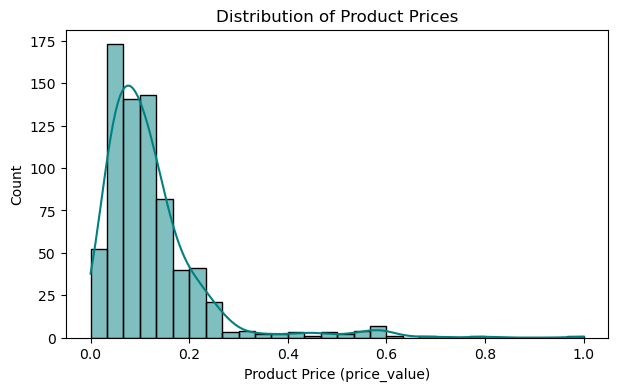

In [133]:
##This plot shows how product prices are distributed. Look for skewness or multimodal patterns.
plt.figure(figsize=(7,4))
sns.histplot(products['price_value'], bins=30, kde=True, color='teal')
plt.xlabel('Product Price (price_value)')
plt.ylabel('Count')
plt.title('Distribution of Product Prices')
plt.show()

#### 2. Boxplot

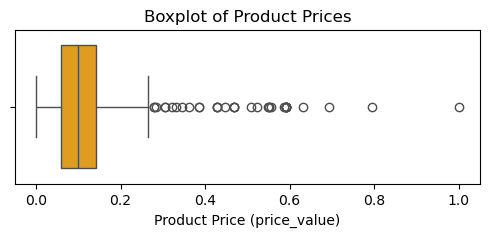

In [143]:
##This shows the median, quartiles and potential outliers in price.

plt.figure(figsize=(6,2))
sns.boxplot(x=products['price_value'], color='orange')
plt.xlabel('Product Price (price_value)')
plt.title('Boxplot of Product Prices')
plt.show()

### 2)Bivariate/multivariate analysis — pairplots, correlation heatmaps.
In this step, we introduce additional variables such as **rating_stars**, **rating_count** and **best_sellers_rank** alongside **price_value** to visualize their pairwise relationships. By using correlation heatmaps and pairplots, we aim to understand how these key product metrics interact with one another, which can reveal important patterns for e-commerce strategy and decision making.

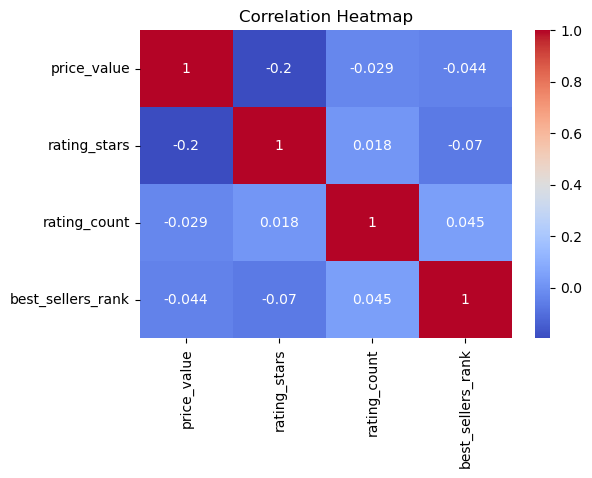

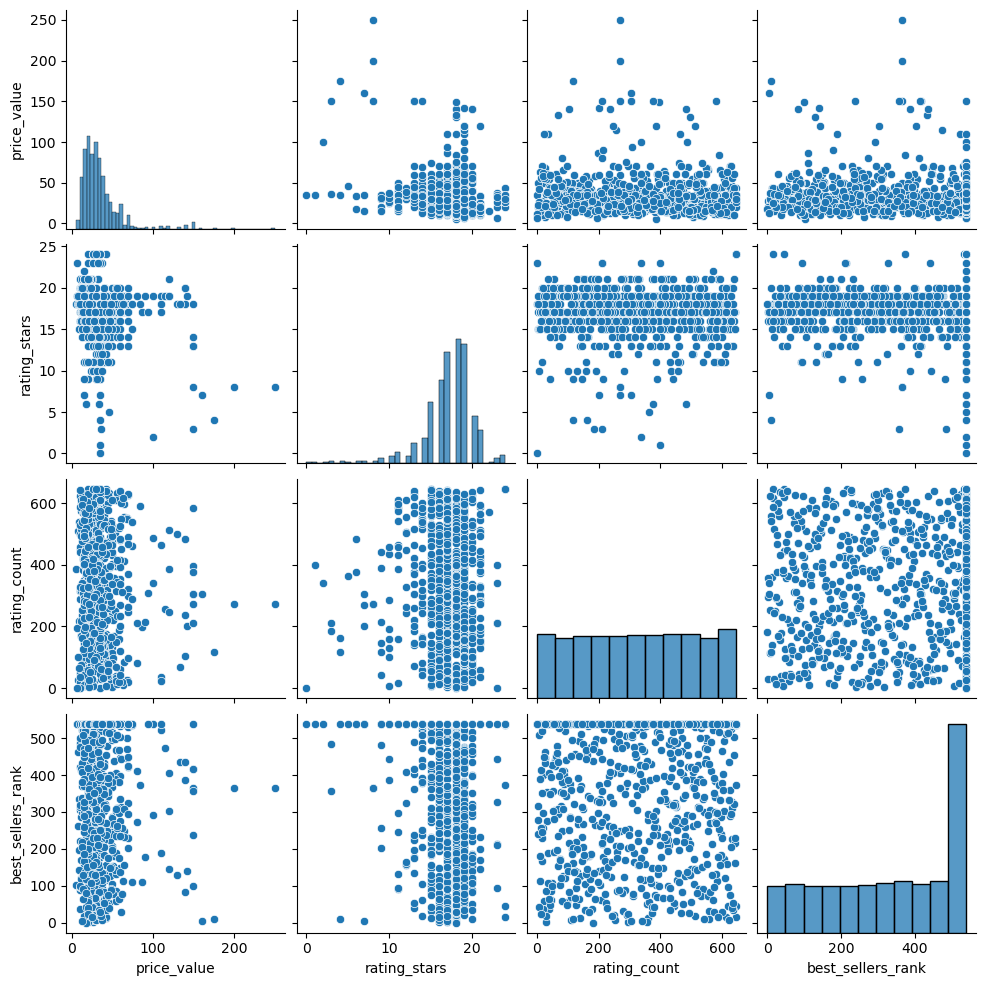

In [33]:
# For correlation heatmap (if you add more columns
num_cols = ['price_value', 'rating_stars', 'rating_count', 'best_sellers_rank']
plt.figure(figsize=(6,4))
sns.heatmap(products[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# For pairplot (optional, only if you want to analyze relationships)
sns.pairplot(products[num_cols].dropna())
plt.show()

### 3) Use descriptive statistics (mean, median, std, skewness, kurtosis).
In this step, we generate descriptive statistics for the **price_value** column to understand its central tendency, variability and overall distribution. Metrics like mean, median, standard deviation, skewness and kurtosis help identify typical prices, spread and any asymmetry or outliers.

In [37]:
print(products['price_value'].describe())
print('\nSkewness:', products['price_value'].skew())
print('Kurtosis:', products['price_value'].kurt())

count    728.000000
mean      35.323948
std       26.037924
min        5.457300
25%       19.990000
50%       29.561300
75%       40.006700
max      249.990000
Name: price_value, dtype: float64

Skewness: 3.1679129081347153
Kurtosis: 14.46005477749309


## Insights Identified from EDA
Analysis of the products dataset shows that price_value is heavily right-skewed, with most products in the lower price range and a handful of very high-priced outliers. Heatmaps and pairplots reveal weak correlations between price and both average rating or review count, meaning expensive products aren’t necessarily rated higher or reviewed more often. Outliers and a wide spread in both prices and review counts highlight the diversity within the product range and signal that premium products or anomalies exist alongside more typical items.

## Comments on Data Distribution
Since the price distribution is not normal and contains extreme outliers, relying on the mean for summary can be misleading. Skewness and outliers can impact the accuracy of predictive models and statistical analyses, so understanding these aspects helps us decide when to use special preprocessing steps like outlier removal or log transformations to make our analysis and future modeling more reliable.

# Step 4:  Statistical Analysis & Hypothesis Testing
In this step, we perform statistical analysis to validate insights from the dataset. This includes:
1) Formulating null and alternative hypotheses for comparing prices, ratings or brand differences.
2) Selecting appropriate tests such as t-tests, ANOVA or chi-square depending on the data type.
3) Using p-values and confidence intervals to judge statistical significance and reliability.
4) Interpreting results while considering possible Type I and Type II errors.
5) Ensuring that all conclusions drawn are statistically sound and data-driven.

### 1) Formulate a hypothesis (null & alternative).
Null hypothesis (H₀): There is no linear relationship between product price and average rating.

Alternative hypothesis (H₁): There is a significant linear relationship between product price and average rating.

### 2) Select Statistical Test
Since both variables are numeric, we use the Pearson correlation test.



### 3) Compute

In [63]:
from scipy.stats import pearsonr
import numpy as np

# Clean 'price_value' and 'rating_stars' to ensure numeric data
products['price_value'] = pd.to_numeric(products['price_value'], errors='coerce')
products['rating_stars'] = pd.to_numeric(products['rating_stars'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# Drop rows with missing values in these two columns
df_corr = products[['price_value', 'rating_stars']].dropna()

# Pearson correlation test
corr, p_value = pearsonr(df_corr['price_value'], df_corr['rating_stars'])
print("Correlation:", corr)
print("P-value:", p_value)

# Step 4: 95% Confidence Interval for Pearson's r (using Fisher transformation)
n = len(df_corr)
stderr = 1 / np.sqrt(n - 3)
from math import atanh, tanh
z = atanh(corr)
z_lower = z - 1.96 * stderr
z_upper = z + 1.96 * stderr
ci_lower = tanh(z_lower)
ci_upper = tanh(z_upper)
print("95% Confidence Interval:", (ci_lower, ci_upper))


Correlation: -0.19610518992629553
P-value: 9.607733009679912e-08
95% Confidence Interval: (-0.26499335111551714, -0.1252253569976897)


### 4) Interpreting the results
1. If p-value < 0.05: There is a statistically significant linear relationship between price and rating (reject H₀).
2. If p-value ≥ 0.05: No statistically significant relationship (fail to reject H₀).
3. The correlation coefficient (r) tells you the strength and direction of the relationship:
 a) Close to 0: No linear association
 b) Positive: Higher price tends to go with higher ratings
 c) Negative: Higher price tends to go with lower ratings
4. The confidence interval provides a range where the true correlation likely falls.

### 5) Errors
Type I Error: Finding a significant relationship when none exists (false positive; risk = p-value threshold, usually 0.05).

Type II Error: Not detecting a real relationship due to small sample size or noisy data (false negative).

# Step 5:  Modeling and Pattern Discovery
In this step, we apply K-Means clustering to identify natural groups among products based on features like price, rating and review count. Our goals are:
1) Form useful product clusters using key numerical attributes.
2) Visualize these clusters to understand how products naturally segment.
3) Interpret what each cluster represents in terms of similarity or differences.
4) Highlight the values like clustering reveals market segments, typical product types and outliers helping in recommendations, marketing and inventory planning.

### Select and Prepare Features
Using the numerical columns: **price_value**, **rating_stars** and **rating_count** for clustering. 

Importing important libraries:

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [90]:
#ensuring there are numeric columns only
columns = ['price_value', 'rating_stars', 'rating_count']
X = products[columns].copy()

#removing duplicates if any
for col in columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.dropna()

# Scaling the data for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Choosing the number of clusters(k)
Here, choosing the value of k as 3

In [95]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
X['Cluster'] = clusters

### Visualize


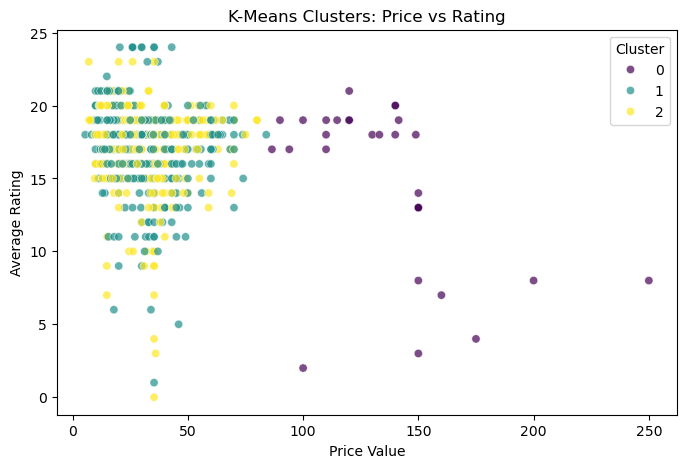

In [100]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=X, x='price_value', y='rating_stars', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('K-Means Clusters: Price vs Rating')
plt.xlabel('Price Value')
plt.ylabel('Average Rating')
plt.show()


### Interpretation
1) Each cluster groups together products with similar price/value, ratings and review counts.
2) For example, one cluster may contain many low priced, highly reviewed items, while another might group more expensive, niche products.

## Step 6: Interpretation & Inference


### Major Findings from EDA and Modeling:
From the exploratory data analysis, we identified that price_value is highly right skewed, with most products falling in a lower price range and a few very high value outliers. There was minimal correlation between product price, rating and customer review counts varied widely across products. Statistical testing (using correlation analysis) confirmed that price and average rating showed no significant linear relationship. K-Means clustering further revealed natural product segments, such as low-cost/high-volume items and premium priced products, supporting targeted marketing strategies.

### Insights, Implications and Business Significance:

These findings show that products follow different pricing patterns and naturally fall into clear market segments. The right skewed prices and the clusters we identified can help plan discounts, manage inventory better and improve recommendation systems. Since price doesn’t strongly affect ratings, relying only on high-priced products might make us overlook affordable items that are actually very popular and well rated. Overall, these patterns help e-commerce teams decide what to stock, promote or recommend so they can cater more effectively to different customer preferences.

### Reflection:

**Patterns identified** Clear segmentation of products based on price and rating, big variations in review counts and a weak overall correlation between price and customer rating.

**Statistical testing validated observations** Tests showed that the relationship between price and ratings was not statistically significant, which supports what we saw during EDA.

**Improvements** Including more features like category, product descriptions or seller details could reveal deeper factors behind product performance. Adding time based features or using stronger sentiment analysis might also help understand market trends better.

## Step 7: Visualization and Presentation


1. Product Availability Status Count
Shows how many products are 'In Stock' vs. 'Out of Stock' or 'Unavailable'.

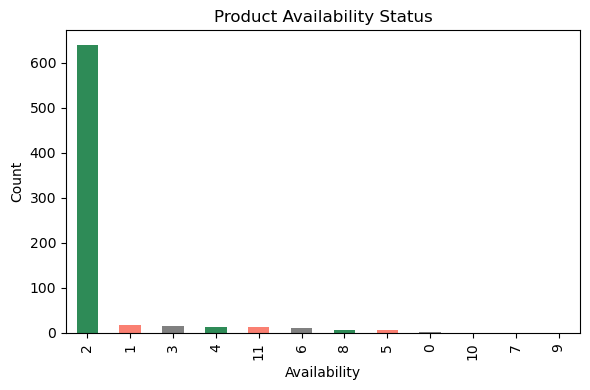

In [117]:
plt.figure(figsize=(6,4))
products['availability'].value_counts().plot(kind='bar', color=['seagreen','salmon','grey'])
plt.title('Product Availability Status')
plt.xlabel('Availability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# Caption: Visualizes stock status for all products.


2. Pie Chart: Product Distribution by Main Category
Breaks down the share of products in top-level categories ('breadcrumbs').

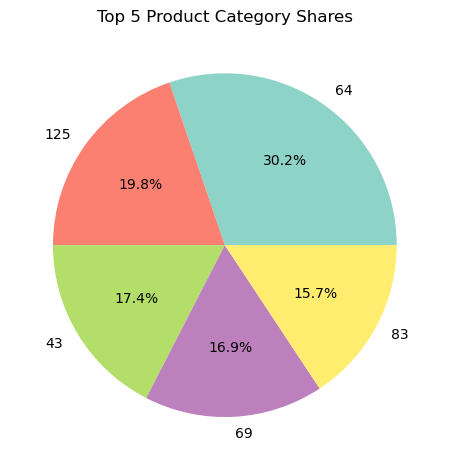

In [120]:
cat_counts = products['breadcrumbs'].value_counts().nlargest(5)
cat_counts.plot.pie(autopct='%1.1f%%', cmap='Set3', ylabel='')
plt.title('Top 5 Product Category Shares')
plt.tight_layout()
plt.show()
# Caption: Proportional distribution of products across major categories.


3. Bar Plot: Products per Seller (Top 8 Sellers)
Highlights market share among the most active or featured sellers.

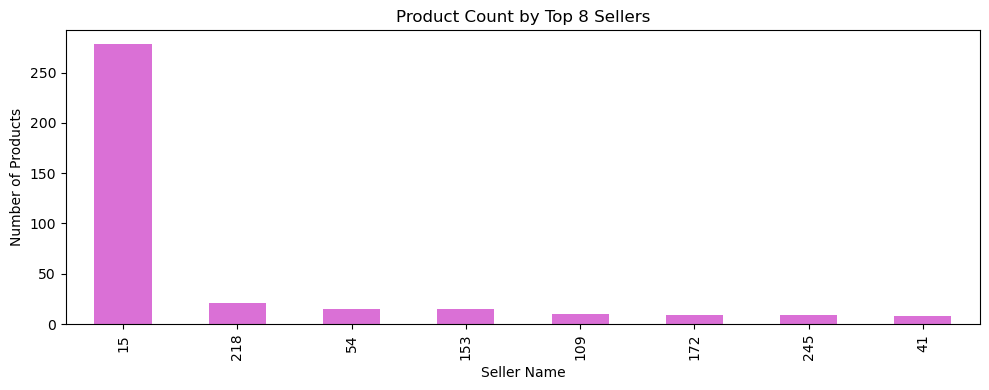

In [124]:
top_sellers = products['seller_name'].value_counts().nlargest(8)
plt.figure(figsize=(10,4))
top_sellers.plot(kind='bar', color='orchid')
plt.title('Product Count by Top 8 Sellers')
plt.xlabel('Seller Name')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()
# Caption: Shows which sellers offer the widest product selection.


4. Boxplot of Rating Counts by Category
Compares customer review counts across major product categories.

C:\Users\HP\AppData\Local\Temp\ipykernel_14676\115761781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='breadcrumbs', y='rating_count',


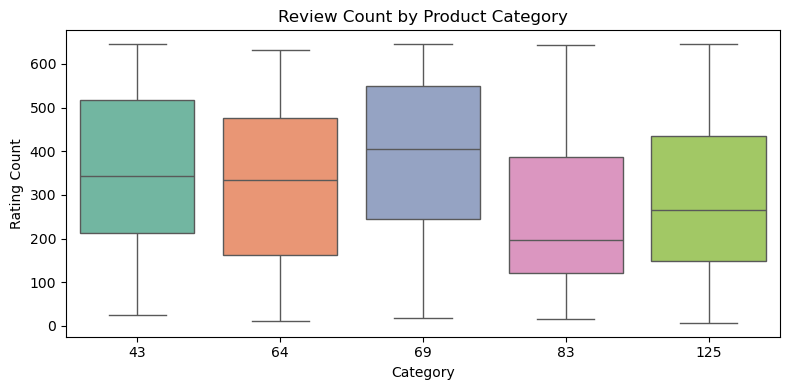

In [127]:
top_categories = products['breadcrumbs'].value_counts().nlargest(5).index
plt.figure(figsize=(8,4))
sns.boxplot(x='breadcrumbs', y='rating_count',
            data=products[products['breadcrumbs'].isin(top_categories)],
            palette='Set2')
plt.title('Review Count by Product Category')
plt.xlabel('Category')
plt.ylabel('Rating Count')
plt.tight_layout()
plt.show()
# Caption: Review activity distribution for leading categories.


## Step 8: Conclusion

### Summary of Findings

The analysis of the Amazon Clothing & Accessories dataset showed clear product segmentation across the catalog. Most prices were concentrated in the lower range, while a small group of premium products created a strong right skew in the price distribution. Ratings and review counts varied a lot but didn’t show any strong correlation with price. Statistical testing confirmed the same, there was no significant linear relationship between product price and average rating.
K-Means clustering also highlighted natural product groups, such as low cost, highly reviewed essentials versus higher priced niche items, showing how unsupervised learning can support better recommendations and market segmentation.

### Limitations

Some useful product features like detailed subcategories, seasonality or deeper sentiment scores were not included, which limited the context of the analysis. The dataset may also miss the latest products or trends. A few columns, especially category text and reviews, needed cleaning due to messy or missing values, which can introduce slight bias. And since K-Means is a basic clustering method, it may not fully capture more complex or nonlinear customer behaviors.

### Future Improvements

Future work can include more features like sentiment analysis on reviews, time based purchase patterns or more detailed category information. Trying advanced models like hierarchical clustering, DBSCAN or deep learning based recommendation methods could provide stronger insights. A larger and more recent dataset would also improve accuracy and help generalize results better.

### Final Takeaway

This project shows how useful data driven analysis can be in e-commerce. We found clear pricing segments and also learned that price alone doesn’t predict customer satisfaction or product popularity. Insights from EDA and clustering can help improve pricing decisions, recommendations and inventory planning. With more detailed features and bigger datasets, even deeper business value can be uncovered helping platforms like Amazon personalize user experience and respond to trends more effectively.

I declare that this mini project was completed mainly through my own effort and understanding. All major tasks including data cleaning, EDA, statistical testing, modeling and interpretation were done by me. I used online resources only for minor help, such as fixing small errors or revising certain concepts and that formed less than 10% of the work. The overall analysis and report reflect my own skills and learning.